## Estadistica Aplicada

Sesion 15 - 18 de Octubre

Bryan Alejandro Estrada Rodriguez 1844554

Grupo: 042


In [ ]:
# librerias Basicas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Especializadas
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Importamos modelo ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict


#Tamaño de graficas
plt.rcParams["figure.figsize"]= (10,6)
plt.rcParams["xtick.labelsize"]= 12
plt.rcParams["ytick.labelsize"]= 12
plt.rcParams["axes.labelsize"]= 12

In [ ]:
igae_deses= pd.read_csv("https://raw.githubusercontent.com/jimmyzac/Estadistica-Aplicada-FCFM-UANL/main/bases_datos/igae_deses.csv")
igae_deses["meses"] = pd.to_datetime(igae_deses["meses"], format="%Y/%m")
igae_deses = igae_deses.set_index("meses")
igae_deses.head()

,IGAE_DESES
meses,
1993-01-01,56.282290
1993-02-01,57.708594
1993-03-01,57.825254
1993-04-01,57.179522
1993-05-01,57.895451


In [ ]:
pip install pmdarima

In [9]:
import pmdarima as pm

# ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
help(pm.auto_arima)
#orden de la arima que estamos buscando

In [12]:
pm.auto_arima(igae_deses["IGAE_DESES"],
              # p= orden de la ar
              # q= orden de la Media mobil
              start_p=1,
              start_q=1,
              max_p=7,
              max_q=7,
              ic='aic',
              seasonal=False)


ARIMA(order=(1, 1, 2), scoring_args={}, suppress_warnings=True)

Se utiliza un sistema akaiko

Deacuerdo con Autoarima nos sugiere que utilicemos un ARIMA(1,1,2)

In [15]:
## ARIMA Estacional
## eries de tiempo con componente estacional
pasajeros = pd.read_csv('https://raw.githubusercontent.com/jimmyzac/Estadistica-Aplicada-FCFM-UANL/main/bases_datos/airline_passengers.csv', index_col='Month', parse_dates=True)

In [16]:
pasajeros=pasajeros.asfreq('MS')

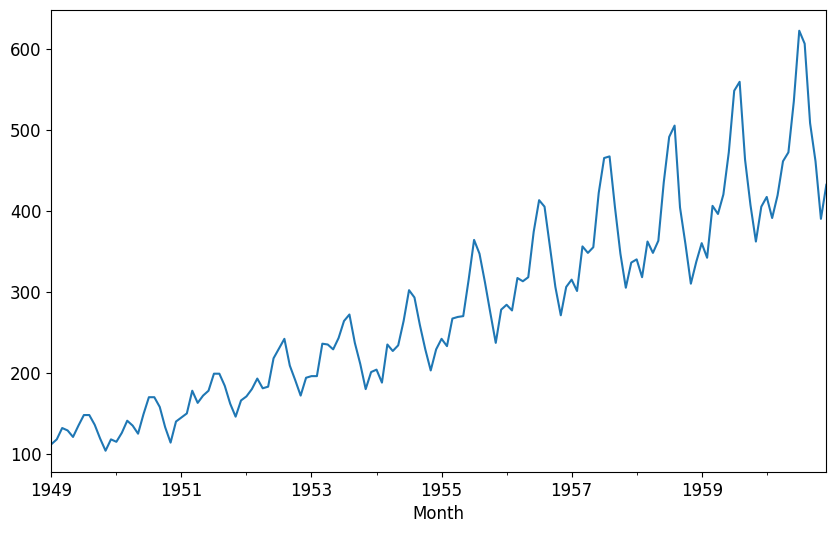

In [17]:
pasajeros['Thousands of Passengers'].plot();

In [18]:
## Comprobar si la serie es estacionaria
prueba_DFA = adfuller(pasajeros['Thousands of Passengers'])
pvalue = prueba_DFA[1]
pvalue

0.991880243437641

No se rechaza H0, la serie ('Thousands of Passengers') es no estacionaria

In [19]:
## Calcular las 1ras diferencias
pasajeros['passengers_diff']= pasajeros['Thousands of Passengers'].diff()

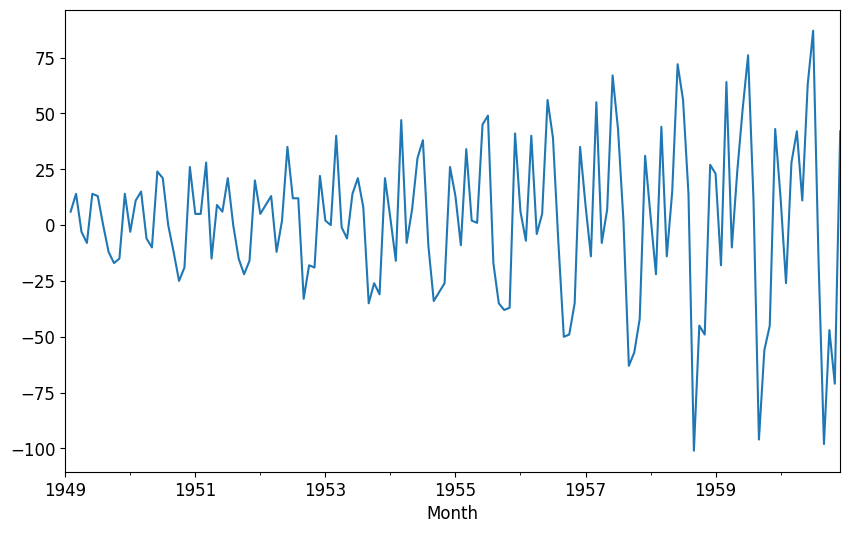

In [21]:
pasajeros['passengers_diff'].plot();

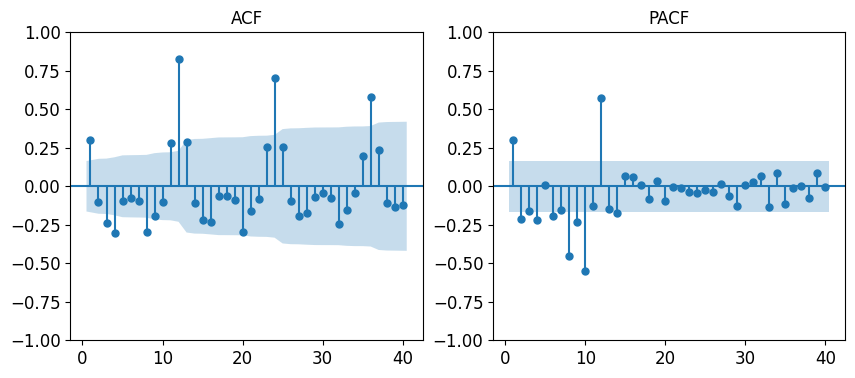

In [24]:
## graficas de autocorrelacion
ig, ax = plt.subplots(1,2,figsize = (10,4))
## 1
plot_acf(pasajeros['passengers_diff'].dropna(),zero=False,lags=40,ax=ax[0],title='ACF')
ax[0].set_ylim(-1,1)
## 2
plot_pacf(pasajeros['passengers_diff'].dropna(),zero=False,lags=40,ax=ax[1],title='PACF')
ax[1].set_ylim(-1,1)
plt.show()

Resago son los valores pasados (Se puede ver como los 3 puntos mas altos, poniendo uno de tras de otro)

tiene un componente estacional porque los meses estan o tienen una fuerte correlacion (Ene=ene, Feb=feb, Dic=dic)

Esta es una serie con componente escional

Enfoque estocastico
* componente estacionario  Media, varianza y covarianza CTE

enfoque clasico
* El componente estacional son esas subidad y bajadas durante los meses del año


In [25]:
pm.auto_arima(pasajeros['Thousands of Passengers'],
              ##ARIMA normal
              start_p=1,
              start_q=1,
              m=12,
              max_p=7,
              max_q=7,
              ## Estacional
              seasonal=True,
              start_P=1,
              start_Q=1,
              max_P=12,
              max_Q=12)

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(2, 1, 0, 12),
      suppress_warnings=True, with_intercept=False)

SARIMA (normal)(Estacional)

SARIMA de la forma (p,I,q)(P,D,Q)

SARIMA (0,1,1)(2,1,0)

In [28]:
# Estimar Modelo
model= ARIMA(pasajeros['Thousands of Passengers'],order=(0,1,1),seasonal_order=(2,1,0,12))# En el Estacional se especificar la frecuencia de los datos (12meses)
results = model.fit()
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:           Thousands of Passengers   No. Observations:                  144
Model:             ARIMA(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                           Wed, 18 Oct 2023   AIC                           1019.178
Time:                                   22:15:59   BIC                           1030.679
Sample:                               01-01-1949   HQIC                          1023.851
                                    - 12-01-1960                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      0.090     -1.372

In [29]:
pasajeros['pronostico']=results.predict()

In [30]:
pasajeros.head()

,Thousands of Passengers,passengers_diff,pronostico
Month,,,
1949-01-01,112,NaN,0.000000
1949-02-01,118,6.0,111.997178
1949-03-01,132,14.0,117.999698
1949-04-01,129,-3.0,131.999295
1949-05-01,121,-8.0,129.000151


In [32]:
pasajeros['pronostico'][0]=pasajeros['Thousands of Passengers'][0]
pasajeros.head()

,Thousands of Passengers,passengers_diff,pronostico
Month,,,
1949-01-01,112,NaN,112.000000
1949-02-01,118,6.0,111.997178
1949-03-01,132,14.0,117.999698
1949-04-01,129,-3.0,131.999295
1949-05-01,121,-8.0,129.000151


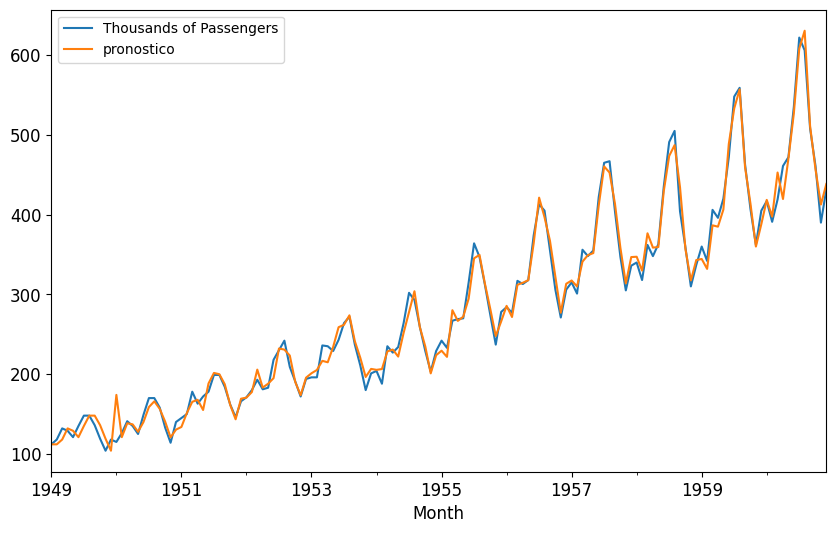

In [33]:
pasajeros['Thousands of Passengers'].plot()
pasajeros['pronostico'].plot()
plt.legend();

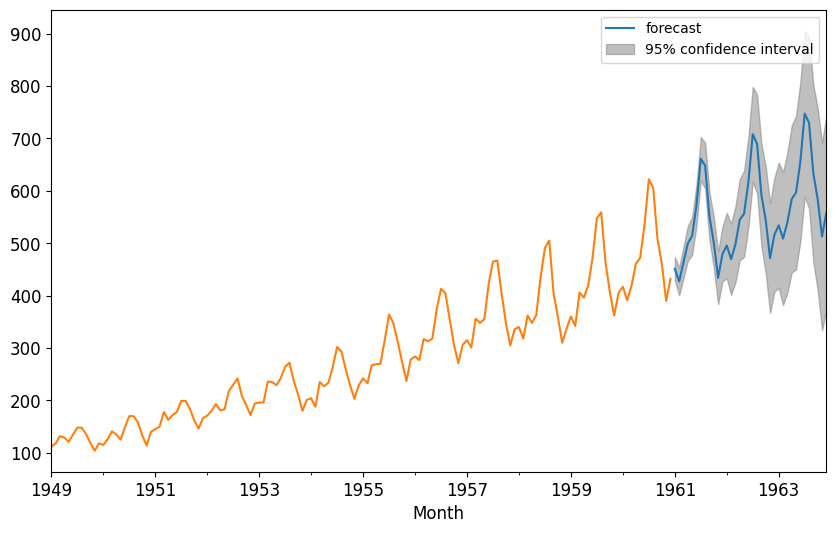

In [35]:
plot_predict(results,start='1961-01-01', end='1963-12-01')
pasajeros['Thousands of Passengers'].plot();

In [34]:
pasajeros.tail(1) # De aqui tomamos la utlima fecha para poder empezar a pronosticar para adelante

,Thousands of Passengers,passengers_diff,pronostico
Month,,,
1960-12-01,432,42.0,438.478199


In [36]:
results.predict(start='1961-01-01', end='1963-12-01')

1961-01-01    451.347077
1961-02-01    427.102222
1961-03-01    463.382490
1961-04-01    499.705771
1961-05-01    514.035526
1961-06-01    571.851868
1961-07-01    661.310509
1961-08-01    648.081675
1961-09-01    551.284692
1961-10-01    501.068280
1961-11-01    434.052984
1961-12-01    479.233768
1962-01-01    495.569171
1962-02-01    469.578457
1962-03-01    497.955025
1962-04-01    544.916439
1962-05-01    556.350008
1962-06-01    616.910053
1962-07-01    708.165788
1962-08-01    689.435154
1962-09-01    592.107044
1962-10-01    544.008548
1962-11-01    471.532195
1962-12-01    516.127936
1963-01-01    534.240092
1963-02-01    508.800961
1963-03-01    539.738523
1963-04-01    584.297672
1963-05-01    596.726150
1963-06-01    655.955971
1963-07-01    747.458852
1963-08-01    729.939147
1963-09-01    632.906670
1963-10-01    583.931321
1963-11-01    512.892705
1963-12-01    558.168625
Freq: MS, Name: predicted_mean, dtype: float64